In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()

data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['species'] = iris.target
data['species'] = data['species'].map({0:'setosa',1:'versicolor',2:'virginica'})

iris_list = data.values.tolist()

print(data.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [2]:
mean_values = data.iloc[:,0:4].mean()
std_values = data.iloc[:,0:4].std()

print("Mean of columns:\n", mean_values)
print("\nStandard Deviation of columns:\n", std_values)

Mean of columns:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

Standard Deviation of columns:
 sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64


In [3]:
mean_values = data.iloc[:,0:4].mean()
std_values = data.iloc[:,0:4].std()

print("Mean of columns:\n", mean_values)
print("\nStandard Deviation of columns:\n", std_values)

Mean of columns:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

Standard Deviation of columns:
 sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64


In [4]:
mean_values = data.iloc[:,0:4].mean()
std_values = data.iloc[:,0:4].std()

print("Mean of columns:\n", mean_values)
print("\nStandard Deviation of columns:\n", std_values)

Mean of columns:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

Standard Deviation of columns:
 sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64


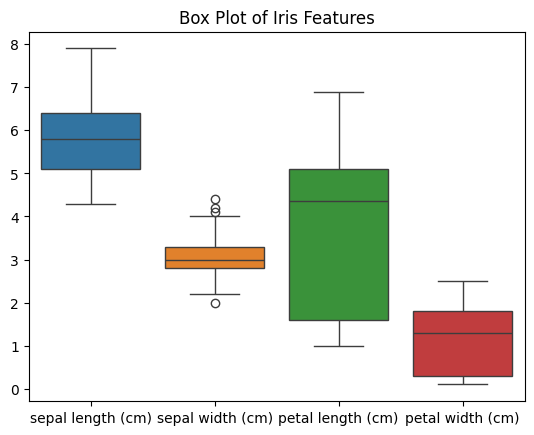

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=data.iloc[:,0:4])
plt.title("Box Plot of Iris Features")
plt.show()

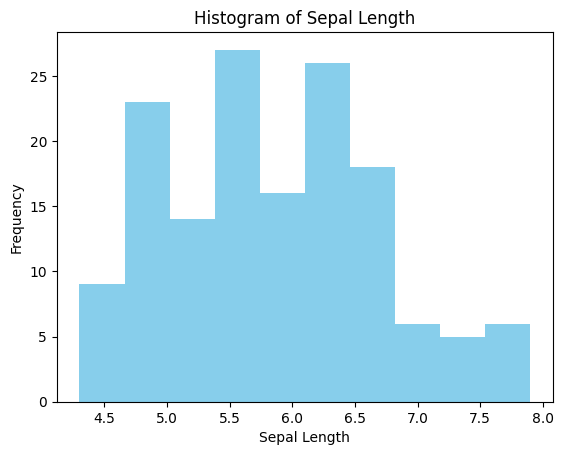

In [7]:
plt.hist(data['sepal length (cm)'], bins=10, color='skyblue')
plt.title("Histogram of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

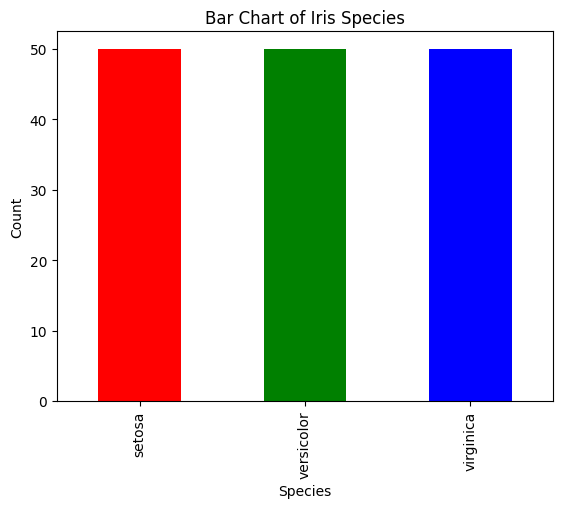

In [8]:
species_count = data['species'].value_counts()

species_count.plot(kind='bar', color=['red','green','blue'])
plt.title("Bar Chart of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

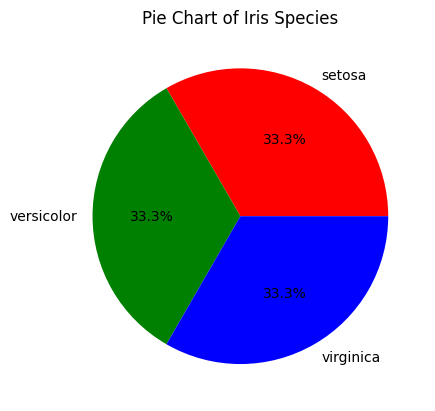

In [9]:
species_count.plot(kind='pie', autopct='%1.1f%%', colors=['red','green','blue'])
plt.title("Pie Chart of Iris Species")
plt.ylabel("")
plt.show()

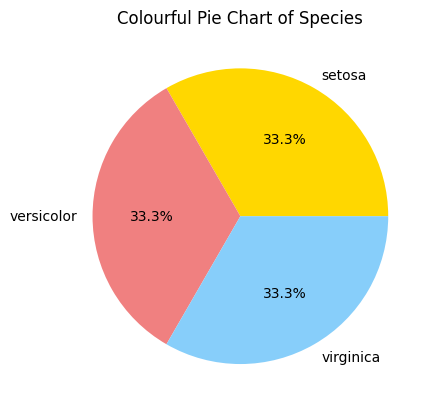

In [10]:
colors = ['gold','lightcoral','lightskyblue']

plt.pie(species_count, labels=species_count.index, autopct='%1.1f%%', colors=colors)
plt.title("Colourful Pie Chart of Species")
plt.show()

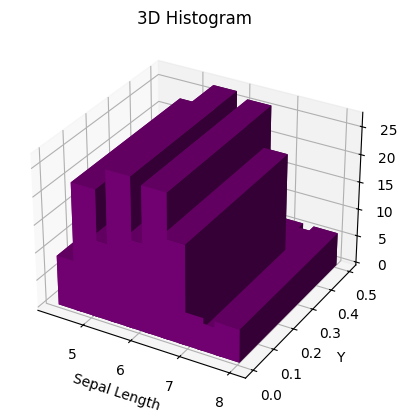

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

hist, xedges = np.histogram(data['sepal length (cm)'], bins=10)

xpos = xedges[:-1]
ypos = np.zeros(len(xpos))
zpos = np.zeros(len(xpos))

dx = 0.5
dy = 0.5
dz = hist

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color='purple')
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Y')
ax.set_zlabel('Frequency')

plt.title("3D Histogram")
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression

X = data[['sepal length (cm)']]
y = data['petal length (cm)']

model = LinearRegression()
model.fit(X,y)

print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [1.85843298]
Intercept: -7.101443369602455


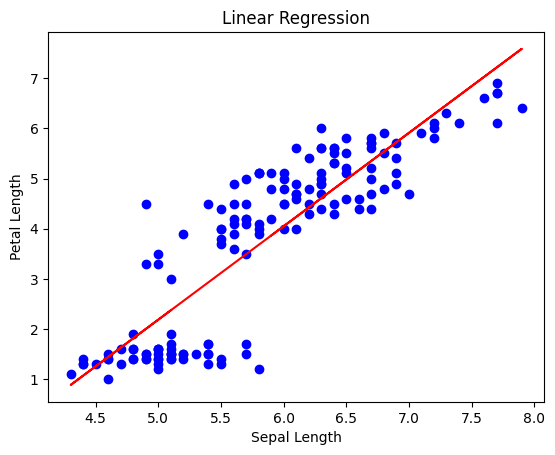

In [13]:
plt.scatter(X,y,color='blue')
plt.plot(X,model.predict(X),color='red')
plt.title("Linear Regression")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.show()

In [14]:
corr_matrix = data.iloc[:,0:4].corr()
print(corr_matrix)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


In [16]:
from scipy.stats import f_oneway

setosa = data[data['species']=='setosa']['sepal length (cm)']
versicolor = data[data['species']=='versicolor']['sepal length (cm)']
virginica = data[data['species']=='virginica']['sepal length (cm)']

f_stat, p_value = f_oneway(setosa, versicolor, virginica)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 119.26450218450468
P-value: 1.6696691907693826e-31
